In [5]:
# ============================================================
# Compare NDBC bulk buoy data with HURRYWAVE bulk stats and
# COAWST/WW3 history output
#
# Uses:
#   - NDBC netCDF already written to disk
#   - user-provided HurryWave reader
#   - fixed COAWST variable names: Hwave, Dwave, Pwave_top
# ============================================================

import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# USER SETTINGS
# ============================================================
NDBC_NC = "F:/crs/proj/2025_NOPP_comparison/helene_waves/ndbc_bulk_with_metadata.nc"
HW_HIS_NC = "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/helene89pervmax/hurrywave_his.nc"
his_url = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "coawst_gomsab_his.nc"
)

NDBC dataset:
<xarray.Dataset> Size: 339kB
Dimensions:              (time: 1172, station: 7)
Coordinates:
  * time                 (time) datetime64[ns] 9kB 2024-09-24 ... 2024-09-28T...
  * station              (station) int32 28B 0 1 2 3 4 5 6
Data variables: (12/15)
    station_id           (station) |S8 56B ...
    station_name         (station) |S128 896B ...
    longitude            (station) float32 28B ...
    latitude             (station) float32 28B ...
    water_depth_m        (station) float32 28B ...
    wave_height          (time, station) float32 33kB ...
    ...                   ...
    wind_speed           (time, station) float32 33kB ...
    wind_direction       (time, station) float32 33kB ...
    wind_gust            (time, station) float32 33kB ...
    air_pressure         (time, station) float32 33kB ...
    air_temperature      (time, station) float32 33kB ...
    water_temperature    (time, station) float32 33kB ...

HURRYWAVE dataset:
<xarray.Dataset> Size: 4

C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_12852\4250551164.py:290: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dfb["time"] = dfb["time"].dt.round("1H")
C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_12852\4250551164.py:290: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dfb["time"] = dfb["time"].dt.round("1H")
C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_12852\4250551164.py:290: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dfb["time"] = dfb["time"].dt.round("1H")
C:\Users\csherwood\AppData\Local\Temp\1\ipykernel_12852\4250551164.py:290: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dfb["time"] = dfb["time"].dt.round("1H")


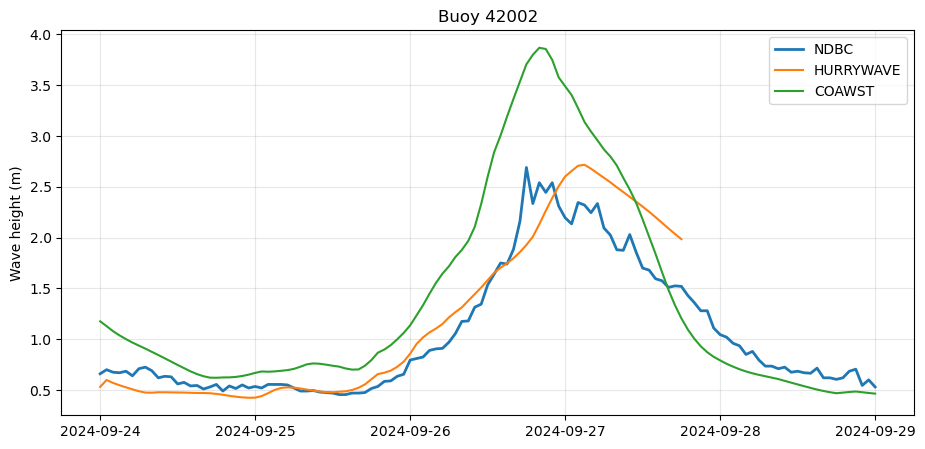

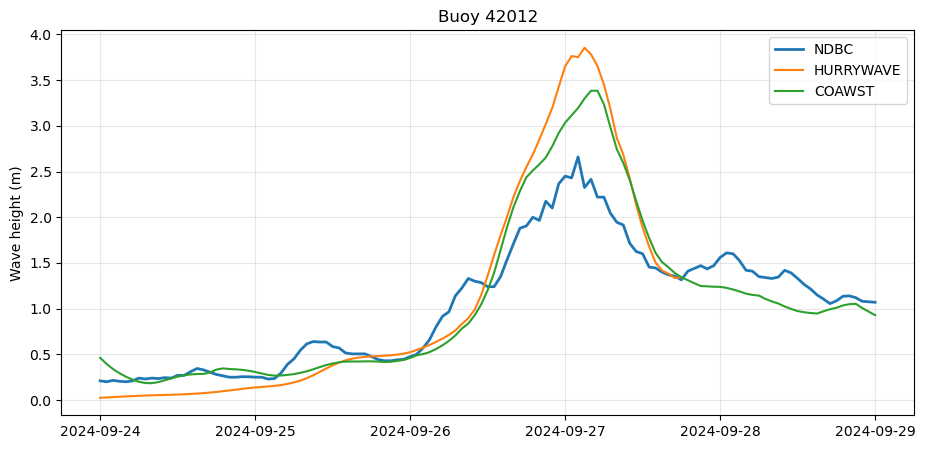

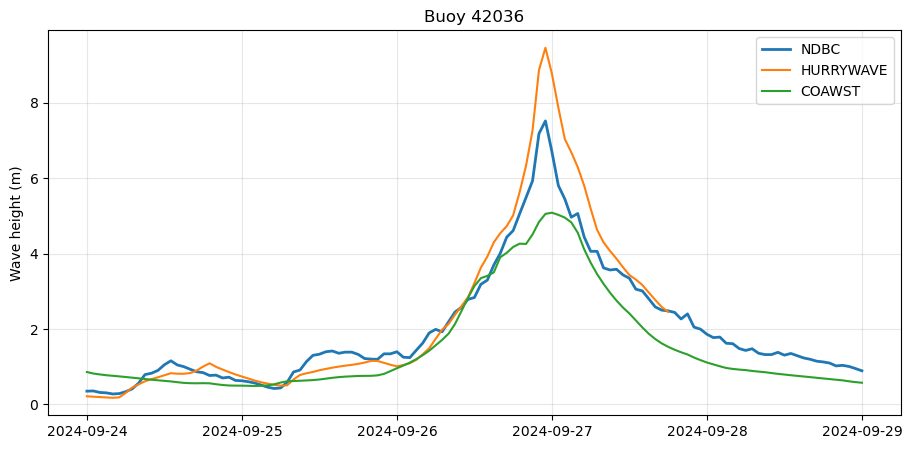

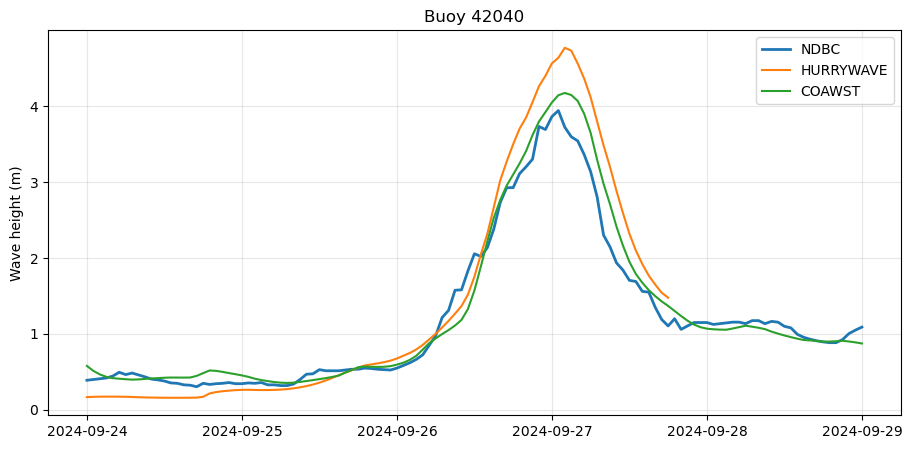

In [9]:
# ============================================================
# Compare NDBC bulk buoy data with HURRYWAVE bulk stats and
# COAWST/WW3 history output
#
# Uses:
#   - NDBC netCDF already written to disk
#   - user-provided HurryWave reader
#   - station matching between HurryWave and NDBC
#   - nearest-hour binning for NDBC
#   - COAWST time axis as master time base
# ============================================================
# ============================================================
# SMALL HELPERS
# ============================================================
def get_time_name(ds):
    for name in ["time", "globaltime", "timemax"]:
        if name in ds.coords or name in ds.variables:
            return name
    raise KeyError("Could not find time variable (expected one of: time, globaltime, timemax)")


def decode_string_array(values):
    arr = np.asarray(values)

    if arr.dtype.kind == "S":
        return np.array([v.decode("utf-8", errors="ignore").strip() for v in arr], dtype=object)

    if arr.dtype.kind == "U":
        return np.array([str(v).strip() for v in arr], dtype=object)

    if arr.ndim == 2:
        out = []
        for row in arr:
            s = "".join(
                x.decode("utf-8", errors="ignore") if isinstance(x, (bytes, np.bytes_)) else str(x)
                for x in row
            )
            out.append(s.strip())
        return np.array(out, dtype=object)

    return np.array([str(v).strip() for v in arr], dtype=object)


def extract_ndbc_id(text):
    if text is None:
        return None
    m = re.search(r"\b(\d{5})\b", str(text))
    return m.group(1) if m else None


def find_hurrywave_station_label_var(ds):
    for name in ["station_name", "station_id", "point_name", "station_label", "name"]:
        if name in ds.variables:
            return name
    return None


def decode_station_strings(da):
    return decode_string_array(da.values)


# ============================================================
# USER-PROVIDED HURRYWAVE READER
# ============================================================
def read_hurrywave_bulk_buoys(his_nc_path, nstations):
    """
    Read first nstations from HurryWave his file.

    Expected variable names:
      point_hm0
      point_tp
      point_wavdir
    """
    ds0 = xr.open_dataset(his_nc_path, mask_and_scale=True, decode_cf=True)
    time_name = get_time_name(ds0)

    hm0_name = "point_hm0"
    tp_name = "point_tp"
    dir_name = "point_wavdir"

    for name in [hm0_name, tp_name, dir_name]:
        if name not in ds0:
            raise KeyError(f"{name} not found in {his_nc_path}")

    dims = ds0[hm0_name].dims
    station_dim = None
    for d in dims:
        if d != time_name:
            station_dim = d
            break
    if station_dim is None:
        raise ValueError(f"Could not infer station dimension from {hm0_name}")

    hm0 = ds0[hm0_name].isel({station_dim: slice(0, nstations)})
    tp = ds0[tp_name].isel({station_dim: slice(0, nstations)})
    wdir = ds0[dir_name].isel({station_dim: slice(0, nstations)})

    out = xr.Dataset(
        coords={
            "time": ds0[time_name].values,
            "station": np.arange(hm0.sizes[station_dim]),
        },
        data_vars={
            "hm0_hw": (("time", "station"), hm0.values),
            "tp_hw": (("time", "station"), tp.values),
            "wdir_from_hw": (("time", "station"), wdir.values),
        },
    )

    label_var = find_hurrywave_station_label_var(ds0)
    if label_var is not None:
        try:
            labels = decode_string_array(ds0[label_var].isel({station_dim: slice(0, nstations)}).values)
            out["station_label_hw"] = ("station", labels)
            out["station_id_guess"] = (
                "station",
                np.array([extract_ndbc_id(lbl) or "" for lbl in labels], dtype=object),
            )
        except Exception:
            pass

    return out


# ============================================================
# MATCH HURRYWAVE TO NDBC
# ============================================================
def build_station_match_table(ds_hw, ds_buoy):
    """
    Prefer matching by station_id extracted from HurryWave labels.
    If that fails, fall back to matching the first N in order.
    """
    buoy_ids = decode_string_array(ds_buoy["station_id"].values)
    buoy_names = decode_string_array(ds_buoy["station_name"].values)

    rows = []

    if "station_id_guess" in ds_hw:
        hw_ids = decode_string_array(ds_hw["station_id_guess"].values)
        hw_labels = (
            decode_string_array(ds_hw["station_label_hw"].values)
            if "station_label_hw" in ds_hw
            else np.array([""] * ds_hw.sizes["station"], dtype=object)
        )

        buoy_lookup = {sid: j for j, sid in enumerate(buoy_ids)}

        for i, sid in enumerate(hw_ids):
            if sid and sid in buoy_lookup:
                j = buoy_lookup[sid]
                rows.append({
                    "hw_station": i,
                    "buoy_station": j,
                    "station_id": sid,
                    "station_label_hw": hw_labels[i],
                    "station_name_buoy": buoy_names[j],
                    "longitude": float(ds_buoy["longitude"].isel(station=j).item()) if "longitude" in ds_buoy else np.nan,
                    "latitude": float(ds_buoy["latitude"].isel(station=j).item()) if "latitude" in ds_buoy else np.nan,
                    "water_depth_m": float(ds_buoy["water_depth_m"].isel(station=j).item()) if "water_depth_m" in ds_buoy else np.nan,
                    "match_method": "station_id_from_hurrywave_label",
                })

    match_df = pd.DataFrame(rows)

    if len(match_df) == 0:
        n = min(ds_hw.sizes["station"], ds_buoy.sizes["station"])
        hw_labels = (
            decode_string_array(ds_hw["station_label_hw"].values)
            if "station_label_hw" in ds_hw
            else np.array([""] * n, dtype=object)
        )

        rows = []
        for i in range(n):
            rows.append({
                "hw_station": i,
                "buoy_station": i,
                "station_id": buoy_ids[i],
                "station_label_hw": hw_labels[i] if i < len(hw_labels) else "",
                "station_name_buoy": buoy_names[i],
                "longitude": float(ds_buoy["longitude"].isel(station=i).item()) if "longitude" in ds_buoy else np.nan,
                "latitude": float(ds_buoy["latitude"].isel(station=i).item()) if "latitude" in ds_buoy else np.nan,
                "water_depth_m": float(ds_buoy["water_depth_m"].isel(station=i).item()) if "water_depth_m" in ds_buoy else np.nan,
                "match_method": "fallback_order",
            })

        match_df = pd.DataFrame(rows)

    return match_df


# ============================================================
# COAWST EXTRACTION
# ============================================================
def find_nearest_roms_point(lon_grid, lat_grid, lon0, lat0):
    dist2 = (lon_grid - lon0) ** 2 + (lat_grid - lat0) ** 2
    j, i = np.unravel_index(np.nanargmin(dist2), lon_grid.shape)
    return j, i


def extract_coawst_to_xarray(ds_his, match_df):
    """
    Extract nearest COAWST point for each matched buoy.
    Output station dimension matches rows of match_df.
    """
    lon_grid = ds_his["lon_rho"].values
    lat_grid = ds_his["lat_rho"].values
    time = pd.to_datetime(ds_his["ocean_time"].values)

    ntime = len(time)
    nstation = len(match_df)

    hwave = np.full((ntime, nstation), np.nan, dtype=float)
    dwave = np.full((ntime, nstation), np.nan, dtype=float)
    pwave = np.full((ntime, nstation), np.nan, dtype=float)
    jj = np.full(nstation, -1, dtype=int)
    ii = np.full(nstation, -1, dtype=int)

    for k, row in match_df.iterrows():
        j, i = find_nearest_roms_point(
            lon_grid, lat_grid,
            float(row["longitude"]),
            float(row["latitude"])
        )
        jj[k] = j
        ii[k] = i
        hwave[:, k] = ds_his["Hwave"][:, j, i].values
        dwave[:, k] = ds_his["Dwave"][:, j, i].values
        pwave[:, k] = ds_his["Pwave_top"][:, j, i].values

    out = xr.Dataset(
        coords={
            "time": time,
            "station": np.arange(nstation),
        },
        data_vars={
            "hwave_cw": (("time", "station"), hwave),
            "dwave_from_cw": (("time", "station"), dwave),
            "pwave_cw": (("time", "station"), pwave),
            "j_coawst": (("station",), jj),
            "i_coawst": (("station",), ii),
            "station_id": (("station",), match_df["station_id"].astype(str).values),
        },
    )

    out["dwave_toward_cw"] = (out["dwave_from_cw"] + 180.0) % 360.0
    return out


# ============================================================
# TIME ALIGNMENT
# ============================================================
def build_ndbc_hourly_matched(ds_buoy, match_df, target_time):
    """
    Build matched NDBC dataset on exact target_time using nearest-hour binning.
    """
    t0 = pd.to_datetime(target_time.min())
    t1 = pd.to_datetime(target_time.max())

    ntime = len(target_time)
    nstation = len(match_df)

    vars_2d = [
        "wave_height",
        "dominant_period",
        "average_period",
        "mean_wave_direction",
    ]
    vars_2d = [v for v in vars_2d if v in ds_buoy]

    data_store = {v: np.full((ntime, nstation), np.nan, dtype=float) for v in vars_2d}

    station_ids = []
    station_names = []
    lons = []
    lats = []
    depths = []

    for k, row in match_df.iterrows():
        j = int(row["buoy_station"])

        dfb = pd.DataFrame({
            "time": pd.to_datetime(ds_buoy["time"].values),
        })

        for v in vars_2d:
            dfb[v] = ds_buoy[v].isel(station=j).values

        dfb = dfb[(dfb["time"] >= (t0 - pd.Timedelta("30min"))) & (dfb["time"] <= (t1 + pd.Timedelta("30min")))].copy()
        dfb["time"] = dfb["time"].dt.round("1H")
        dfb = dfb.groupby("time", as_index=False).mean(numeric_only=True)
        dfb = dfb.set_index("time").reindex(pd.DatetimeIndex(target_time))

        for v in vars_2d:
            data_store[v][:, k] = dfb[v].values

        station_ids.append(str(row["station_id"]))
        station_names.append(str(row["station_name_buoy"]))
        lons.append(float(row["longitude"]))
        lats.append(float(row["latitude"]))
        depths.append(float(row["water_depth_m"]))

    out = xr.Dataset(
        coords={
            "time": pd.to_datetime(target_time),
            "station": np.arange(nstation),
        },
        data_vars={
            "station_id": (("station",), np.asarray(station_ids, dtype=object)),
            "station_name": (("station",), np.asarray(station_names, dtype=object)),
            "longitude": (("station",), np.asarray(lons, dtype=float)),
            "latitude": (("station",), np.asarray(lats, dtype=float)),
            "water_depth_m": (("station",), np.asarray(depths, dtype=float)),
        }
    )

    for v in vars_2d:
        out[v] = (("time", "station"), data_store[v])

    return out


def build_hurrywave_hourly_matched(ds_hw, match_df, target_time):
    """
    Build matched HurryWave dataset on exact target_time using interpolation.
    """
    ntime = len(target_time)
    nstation = len(match_df)

    hm0 = np.full((ntime, nstation), np.nan, dtype=float)
    tp = np.full((ntime, nstation), np.nan, dtype=float)
    wdir = np.full((ntime, nstation), np.nan, dtype=float)

    for k, row in match_df.iterrows():
        i = int(row["hw_station"])

        dsh = ds_hw[["hm0_hw", "tp_hw", "wdir_from_hw"]].isel(station=i).sortby("time")
        dsh_i = dsh.interp(time=target_time)

        hm0[:, k] = dsh_i["hm0_hw"].values
        tp[:, k] = dsh_i["tp_hw"].values
        wdir[:, k] = dsh_i["wdir_from_hw"].values

    out = xr.Dataset(
        coords={
            "time": pd.to_datetime(target_time),
            "station": np.arange(nstation),
        },
        data_vars={
            "hm0_hw": (("time", "station"), hm0),
            "tp_hw": (("time", "station"), tp),
            "wdir_from_hw": (("time", "station"), wdir),
            "station_id": (("station",), match_df["station_id"].astype(str).values),
        },
    )

    out["wdir_toward_hw"] = (out["wdir_from_hw"] + 180.0) % 360.0
    return out


# ============================================================
# BUILD MATCHED TIME SERIES
# ============================================================
def build_pair_dataframe(ds_hw, ds_buoy, hw_station, buoy_station, time_tol="30min"):
    df_hw = pd.DataFrame({
        "time": pd.to_datetime(ds_hw["time"].values),
        "hm0_hw": ds_hw["hm0_hw"].isel(station=hw_station).values,
        "tp_hw": ds_hw["tp_hw"].isel(station=hw_station).values,
        "wdir_from_hw": ds_hw["wdir_from_hw"].isel(station=hw_station).values,
    }).sort_values("time")

    df_buoy = pd.DataFrame({
        "time": pd.to_datetime(ds_buoy["time"].values),
        "wvht_buoy": ds_buoy["wave_height"].isel(station=buoy_station).values,
        "dpd_buoy": ds_buoy["dominant_period"].isel(station=buoy_station).values if "dominant_period" in ds_buoy else np.nan,
        "apd_buoy": ds_buoy["average_period"].isel(station=buoy_station).values if "average_period" in ds_buoy else np.nan,
        "mwd_from_buoy": ds_buoy["mean_wave_direction"].isel(station=buoy_station).values if "mean_wave_direction" in ds_buoy else np.nan,
    }).sort_values("time")

    df = pd.merge_asof(
        df_hw,
        df_buoy,
        on="time",
        direction="nearest",
        tolerance=pd.Timedelta(time_tol),
    )

    return df


# ============================================================
# FINAL LONG DATAFRAME
# ============================================================
def xr_to_long_df(ds_ndbc, ds_hw, ds_cw):
    station_ids = decode_station_strings(ds_ndbc["station_id"])
    station_names = decode_station_strings(ds_ndbc["station_name"])
    lons = ds_ndbc["longitude"].values
    lats = ds_ndbc["latitude"].values
    depths = ds_ndbc["water_depth_m"].values
    time = pd.to_datetime(ds_ndbc["time"].values)

    ntime = ds_ndbc.sizes["time"]
    nstation = ds_ndbc.sizes["station"]

    rows = []
    for k in range(nstation):
        dfk = pd.DataFrame({
            "time": time,
            "station": k,
            "station_id": str(station_ids[k]).strip(),
            "station_name": str(station_names[k]).strip(),
            "longitude": float(lons[k]),
            "latitude": float(lats[k]),
            "water_depth_m": float(depths[k]),
            "wave_height_ndbc": ds_ndbc["wave_height"][:, k].values,
            "dominant_period_ndbc": ds_ndbc["dominant_period"][:, k].values if "dominant_period" in ds_ndbc else np.full(ntime, np.nan),
            "average_period_ndbc": ds_ndbc["average_period"][:, k].values if "average_period" in ds_ndbc else np.full(ntime, np.nan),
            "mean_wave_direction_ndbc": ds_ndbc["mean_wave_direction"][:, k].values if "mean_wave_direction" in ds_ndbc else np.full(ntime, np.nan),
            "hm0_hw": ds_hw["hm0_hw"][:, k].values,
            "tp_hw": ds_hw["tp_hw"][:, k].values,
            "wdir_from_hw": ds_hw["wdir_from_hw"][:, k].values,
            "hwave_cw": ds_cw["hwave_cw"][:, k].values,
            "pwave_cw": ds_cw["pwave_cw"][:, k].values,
            "dwave_from_cw": ds_cw["dwave_from_cw"][:, k].values,
        })
        rows.append(dfk)

    df = pd.concat(rows, ignore_index=True)
    df["wdir_toward_hw"] = (df["wdir_from_hw"] + 180.0) % 360.0
    df["dwave_toward_cw"] = (df["dwave_from_cw"] + 180.0) % 360.0
    return df


def calc_basic_stats(obs, mod):
    m = np.isfinite(obs) & np.isfinite(mod)
    if m.sum() == 0:
        return {"N": 0, "bias": np.nan, "rmse": np.nan, "corr": np.nan}

    o = np.asarray(obs[m], dtype=float)
    p = np.asarray(mod[m], dtype=float)

    return {
        "N": int(len(o)),
        "bias": np.mean(p - o),
        "rmse": np.sqrt(np.mean((p - o) ** 2)),
        "corr": np.corrcoef(o, p)[0, 1] if len(o) > 1 else np.nan,
    }


def make_stats_table(df):
    rows = []
    for station_id, g in df.groupby("station_id"):
        s_hw = calc_basic_stats(g["wave_height_ndbc"].values, g["hm0_hw"].values)
        s_cw = calc_basic_stats(g["wave_height_ndbc"].values, g["hwave_cw"].values)

        rows.append({
            "station_id": station_id,
            "N_hw": s_hw["N"],
            "bias_hw": s_hw["bias"],
            "rmse_hw": s_hw["rmse"],
            "corr_hw": s_hw["corr"],
            "N_cw": s_cw["N"],
            "bias_cw": s_cw["bias"],
            "rmse_cw": s_cw["rmse"],
            "corr_cw": s_cw["corr"],
        })

    return pd.DataFrame(rows).sort_values("station_id").reset_index(drop=True)


def plot_wave_height_comparison(df, station_id):
    g = df[df["station_id"] == str(station_id)].sort_values("time").copy()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(g["time"], g["wave_height_ndbc"], lw=2, label="NDBC")
    ax.plot(g["time"], g["hm0_hw"], lw=1.5, label="HURRYWAVE")
    ax.plot(g["time"], g["hwave_cw"], lw=1.5, label="COAWST")

    ax.set_title(f"Buoy {station_id}")
    ax.set_ylabel("Wave height (m)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


# ============================================================
# READ NDBC AND HURRYWAVE
# ============================================================
ds_buoy = xr.open_dataset(NDBC_NC)
nstations_buoy = ds_buoy.sizes["station"]

print("NDBC dataset:")
print(ds_buoy)
print()

ds_hw = read_hurrywave_bulk_buoys(HW_HIS_NC, nstations=9999)

print("HURRYWAVE dataset:")
print(ds_hw)
print()

# ============================================================
# BUILD STATION MATCH TABLE
# ============================================================
match_df = build_station_match_table(ds_hw, ds_buoy)

print("Station match table:")
print(match_df)
print()

# keep only matched HurryWave stations
ds_hw_matched = xr.Dataset(
    coords={
        "time": ds_hw["time"].values,
        "station": np.arange(len(match_df)),
    },
    data_vars={
        "hm0_hw": (("time", "station"), np.column_stack([
            ds_hw["hm0_hw"].isel(station=int(i)).values for i in match_df["hw_station"].values
        ])),
        "tp_hw": (("time", "station"), np.column_stack([
            ds_hw["tp_hw"].isel(station=int(i)).values for i in match_df["hw_station"].values
        ])),
        "wdir_from_hw": (("time", "station"), np.column_stack([
            ds_hw["wdir_from_hw"].isel(station=int(i)).values for i in match_df["hw_station"].values
        ])),
        "station_id": (("station",), match_df["station_id"].astype(str).values),
    },
)
if "station_label_hw" in ds_hw:
    ds_hw_matched["station_label_hw"] = (("station",), match_df["station_label_hw"].astype(str).values)

# ============================================================
# READ COAWST AND EXTRACT AT MATCHED BUOY LOCATIONS
# ============================================================
ds_his = xr.open_dataset(his_url)
ds_cw = extract_coawst_to_xarray(ds_his, match_df)

print("COAWST extracted dataset:")
print(ds_cw)
print()

# ============================================================
# ALIGN ALL TO COAWST TIME AXIS
# ============================================================
target_time = pd.to_datetime(ds_cw["time"].values)

ds_buoy_a = build_ndbc_hourly_matched(ds_buoy, match_df, target_time)
ds_hw_a = build_hurrywave_hourly_matched(ds_hw_matched, match_df.assign(hw_station=np.arange(len(match_df))), target_time)
ds_cw_a = ds_cw.assign_coords(time=target_time)

print("Aligned sizes:")
print("NDBC   :", ds_buoy_a.sizes)
print("HW     :", ds_hw_a.sizes)
print("COAWST :", ds_cw_a.sizes)
print()

print("Non-NaN counts after alignment:")
print("NDBC wave_height:", np.isfinite(ds_buoy_a["wave_height"].values).sum())
print("HW hm0_hw      :", np.isfinite(ds_hw_a["hm0_hw"].values).sum())
print("CW hwave_cw    :", np.isfinite(ds_cw_a["hwave_cw"].values).sum())
print()

# ============================================================
# COMBINED DATAFRAME
# ============================================================
df_all = xr_to_long_df(ds_buoy_a, ds_hw_a, ds_cw_a)

print("Combined dataframe head:")
print(df_all.head())
print()

print("Record counts by station:")
print(df_all.groupby("station_id").size())
print()

# ============================================================
# STATS
# ============================================================
stats_df = make_stats_table(df_all)

print("Wave-height comparison stats:")
print(stats_df)
print()

# ============================================================
# PLOTS
# ============================================================
for sid in match_df["station_id"].astype(str).values:
    plot_wave_height_comparison(df_all, sid)

In [7]:
ds_ndbc

<xarray.Dataset> Size: 339kB
Dimensions:              (time: 1172, station: 7)
Coordinates:
  * time                 (time) datetime64[ns] 9kB 2024-09-24 ... 2024-09-28T...
  * station              (station) int32 28B 0 1 2 3 4 5 6
Data variables: (12/15)
    station_id           (station) |S8 56B b'42002' b'42012' ... b'42098'
    station_name         (station) |S128 896B b'NDBC 42002 (LLNR 1470) - West...
    longitude            (station) float32 28B -93.78 -87.55 ... -83.65 -82.93
    latitude             (station) float32 28B 25.95 30.06 27.17 ... 25.7 27.59
    water_depth_m        (station) float32 28B ...
    wave_height          (time, station) float32 33kB ...
    ...                   ...
    wind_speed           (time, station) float32 33kB ...
    wind_direction       (time, station) float32 33kB ...
    wind_gust            (time, station) float32 33kB ...
    air_pressure         (time, station) float32 33kB ...
    air_temperature      (time, station) float32 33kB ...
    water_temperature    (time, station) float32 33kB ...